# 1) Chargement des données

In [116]:
# Importer les bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [117]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/P12/billets.csv"
df = pd.read_csv(DATA_PATH, sep=";")

print(" Données chargées :", df.shape)
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


# 2) Analyse exploratoire (EDA)


## Vue générale du jeu de données





In [118]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


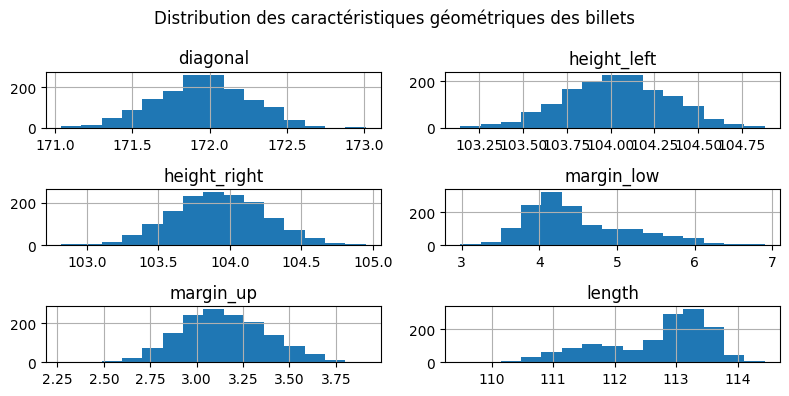

In [119]:
# Visualiser la distribution des six caractéristiques géométriques
df[
    ["diagonal", "height_left", "height_right",
     "margin_low", "margin_up", "length"]
].hist(figsize=(8, 4), bins=15)

plt.suptitle("Distribution des caractéristiques géométriques des billets")
plt.tight_layout()
plt.show()

### Analyse de la distribution des caractéristiques géométriques

Les distributions montrent que les caractéristiques géométriques des billets ne présentent pas toutes le même comportement.

Les variables `diagonal`, `height_left`, `height_right` et `margin_up` sont relativement concentrées autour de leur moyenne.

Les variables `margin_low` et `length` présentent davantage de dispersion et semblent mieux différencier certains groupes de billets.

Ces différences peuvent être utiles pour les modèles de classification afin de distinguer les billets authentiques des faux billets.

In [120]:
# Nombre de valeurs manquantes par variable
valeurs_manquantes = df.isna().sum()
print(valeurs_manquantes)

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64


In [121]:
# Pourcentage de valeurs manquantes
pourcentage_manquant = (df.isna().mean() * 100).round(2)
print(pourcentage_manquant)

is_genuine      0.00
diagonal        0.00
height_left     0.00
height_right    0.00
margin_low      2.47
margin_up       0.00
length          0.00
dtype: float64


In [122]:
missing_df = pd.DataFrame({
    "Valeurs manquantes": valeurs_manquantes,
    "Pourcentage (%)": pourcentage_manquant
})

display(missing_df)

,Valeurs manquantes,Pourcentage (%)
is_genuine,0,0.00
diagonal,0,0.00
height_left,0,0.00
height_right,0,0.00
margin_low,37,2.47
margin_up,0,0.00
length,0,0.00


In [123]:
# Observer les billets pour lesquels margin_low est manquant
df[df["margin_low"].isna()].head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
72,True,171.94,103.89,103.45,NaN,3.25,112.79
99,True,171.93,104.07,104.18,NaN,3.14,113.08
151,True,172.07,103.80,104.38,NaN,3.02,112.93
197,True,171.45,103.66,103.80,NaN,3.62,113.27
241,True,171.83,104.14,104.06,NaN,3.02,112.36


### Analyse des valeurs manquantes

L'analyse de la qualité des données met en évidence des valeurs manquantes
uniquement pour la variable `margin_low`.

Sur les 1 500 observations du jeu de données, 1 463 valeurs sont renseignées
pour cette variable, soit 37 valeurs manquantes (environ 2,47 %).

Les autres variables géométriques ne présentent pas de valeurs manquantes.

La variable `margin_low` faisant partie des caractéristiques utilisées pour
la classification des billets, ces valeurs manquantes doivent être traitées
avant la phase de modélisation.

### Répartition des classes parmi les valeurs manquantes

In [124]:
# Afficher la répartition globale des billets authentiques et faux
df["is_genuine"].value_counts()

,count
is_genuine,
True,1000
False,500


In [125]:
# Répartition vrai/faux parmi les valeurs manquantes
df.loc[df["margin_low"].isna(), "is_genuine"].value_counts()

,count
is_genuine,
True,29
False,8


In [126]:
# Séparation des données selon la présence de margin_low

df_complet = df[df["margin_low"].notna()].copy()
df_manquant = df[df["margin_low"].isna()].copy()

print("Billets avec margin_low :", len(df_complet))
print("Billets sans margin_low :", len(df_manquant))

Billets avec margin_low : 1463
Billets sans margin_low : 37


In [127]:
# Variables explicatives utilisées pour prédire margin_low
features = [
    "diagonal",
    "height_left",
    "height_right",
    "margin_up",
    "length"]

# X = variables utilisées pour faire la prédiction
X = df_complet[features]

# y = variable que l'on cherche à prédire
y = df_complet["margin_low"]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (1463, 5)
Dimensions de y : (1463,)


In [128]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Séparation des données : 80 % pour l'entraînement, 20 % pour le test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

regression = LinearRegression()
# Entraînement
regression.fit(X_train, y_train)

# Prédiction de margin_low sur les données de test
y_pred = regression.predict(X_test)

print("Données d'entraînement :", X_train.shape)
print("Données de test :", X_test.shape)

Données d'entraînement : (1170, 5)
Données de test : (293, 5)


### Entraînement de la régression linéaire

Le modèle est entraîné sur 80 % des données complètes et évalué sur les 20 % restants.

La standardisation n'est pas appliquée ici. La régression linéaire est utilisée pour prédire `margin_low` à partir des cinq autres caractéristiques géométriques du billet.

In [129]:
# Comparaison entre les valeurs réelles et les valeurs prédites
comparaison = pd.DataFrame({
    "margin_low_reelle": y_test.values,
    "margin_low_predite": y_pred
})

comparaison.head(10)

,margin_low_reelle,margin_low_predite
0,5.19,4.956639
1,4.26,4.298382
2,4.18,4.377730
3,3.93,4.095289
4,4.25,4.022746
5,4.61,4.095568
6,5.55,4.853338
7,4.26,4.127876
8,3.75,4.200969
9,4.00,3.861864


### Comparaison des valeurs réelles et prédites

Le modèle de régression linéaire a été utilisé pour prédire `margin_low` sur le jeu de test.

On compare les valeurs prédites aux valeurs réelles afin de vérifier la qualité des prédictions.

Les résultats montrent que les prédictions sont globalement proches des valeurs réelles, avec toutefois certains écarts plus importants.

La prochaine étape consiste à mesurer précisément ces erreurs à l'aide de métriques d'évaluation.

In [130]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Évaluation du modèle
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.3354
RMSE : 0.4375
R²   : 0.5458


### Évaluation de la régression linéaire

Le modèle obtient une MAE de 0,335 mm et une RMSE de 0,438 mm.

Cela signifie que les prédictions de `margin_low` présentent en moyenne un écart d'environ 0,34 mm par rapport aux valeurs réelles.

Le R² est de 0,546 : le modèle explique environ 54,6 % de la variabilité de `margin_low`.

Les performances sont modérées, mais la régression permet d'estimer les valeurs manquantes à partir des autres caractéristiques géométriques.

### Étape 1 — Entraîner le modèle final

In [131]:
# Modèle final pour l'imputation de margin_low
regression_finale = LinearRegression()

In [132]:
# Entraînement sur les 1463 billets complets
regression_finale.fit(
    df_complet[features],
    df_complet["margin_low"])

LinearRegression()

AVANT
1463 billets
   ↓
80 % apprentissage
20 % test
   ↓
ÉVALUER le modèle


MAINTENANT
1463 billets complets
   ↓
Régression linéaire finale
   ↓
PRÉDIRE les 37 valeurs manquantes

###Étape 2 — Prédire les 37 valeurs

In [133]:
# Variables explicatives des billets avec margin_low manquant
X_manquant = df_manquant[features]

In [134]:
# Prédiction des 37 valeurs manquantes
margin_low_predites = regression_finale.predict(X_manquant)

print("Nombre de valeurs prédites :", len(margin_low_predites))
margin_low_predites[:10]

Nombre de valeurs prédites : 37


array([4.31852466, 4.39366755, 4.41045663, 4.31901423, 4.6506171 ,
       3.80330831, 4.17973608, 4.12744154, 4.13503418, 4.16053851])

In [135]:
# Remplacer les NaN de margin_low par les valeurs prédites
# .loc permet de cibler précisément les lignes selon une condition et la colonne à modifier
df.loc[df["margin_low"].isna(), "margin_low"] = margin_low_predites

In [136]:
#Vérifier qu'il ne reste aucune valeur manquante dans margin_low
df["margin_low"].isna().sum()

np.int64(0)

In [137]:
#verificqtion jeu de donnés
df.isna().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,0
margin_up,0
length,0


In [138]:
# Sauvegarder le jeu de données nettoyé dans Google Drive
chemin_df_nettoye = "/content/drive/MyDrive/Colab Notebooks/P12/billets_nettoyes.csv"

df.to_csv(
    chemin_df_nettoye,
    sep=";",
    index=False)

print("Jeu de données nettoyé sauvegardé.")

Jeu de données nettoyé sauvegardé.


### Imputation des valeurs manquantes

Les 37 valeurs manquantes de `margin_low` ont été estimées à l'aide d'une régression linéaire entraînée sur les 1 463 billets complets.

Les valeurs prédites ont ensuite été intégrées dans le jeu de données.

Après imputation, aucune valeur manquante ne subsiste dans le dataset.

In [139]:
# Définir la variable cible y : indique si le billet est authentique (True) ou faux (False)
y = df["is_genuine"]

In [140]:
# Définir les variables explicatives X : les 6 caractéristiques géométriques du billet
X = df[
    ["diagonal", "height_left", "height_right",
     "margin_low", "margin_up", "length"]]

In [141]:
print("X :", X.shape)
print("y :", y.shape)

X : (1500, 6)
y : (1500,)


### Définition des variables explicatives et de la cible

Pour la classification des billets, les six caractéristiques géométriques sont utilisées comme variables explicatives `X` :

- `diagonal`
- `height_left`
- `height_right`
- `margin_low`
- `margin_up`
- `length`

La variable `is_genuine` correspond à la cible `y` que les modèles devront prédire :

- `True` : billet authentique
- `False` : billet faux

Le jeu de données contient 1 500 billets, soit 1 500 observations pour `X` et pour `y`.

# 3) Préparation des données pour la classification

### Séparation des données en jeu d'entraînement et jeu de test

Le jeu de données est séparé en deux parties :

- 80 % des données sont utilisées pour entraîner les modèles ;
- 20 % sont conservées pour évaluer leurs performances sur des données qu'ils n'ont jamais vues.

La séparation est effectuée sur les variables explicatives `X` et la cible `y`.

In [142]:
# Import de la fonction de séparation des données
from sklearn.model_selection import train_test_split

# Séparation des données : 80 % pour l'entraînement, 20 % pour le test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

In [143]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1200, 6)
X_test  : (300, 6)
y_train : (1200,)
y_test  : (300,)


In [144]:
# Vérifier la répartition des classes dans les jeux d'entraînement et de test
print("Répartition y_train :")
print(y_train.value_counts(normalize=True))

print("\nRépartition y_test :")
print(y_test.value_counts(normalize=True))

Répartition y_train :
is_genuine
True     0.666667
False    0.333333
Name: proportion, dtype: float64

Répartition y_test :
is_genuine
True     0.666667
False    0.333333
Name: proportion, dtype: float64


#### Vérification de la répartition des classes

Grâce à `stratify=y`, la proportion des classes est conservée après la séparation des données.

Le jeu d'entraînement et le jeu de test contiennent chacun environ :
- 66,7 % de billets authentiques (`True`) ;
- 33,3 % de billets faux (`False`).

Cela permet d'évaluer les modèles sur un jeu de test représentatif de la répartition initiale des données.

# 4) Modélisation


## Régression logistique

La régression logistique est un algorithme de classification supervisée.

Dans ce projet, elle est utilisée pour prédire si un billet est authentique (`True`) ou faux (`False`) à partir de ses six caractéristiques géométriques.

In [145]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42)

In [146]:
# Entraîner la régression logistique
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Entraînement du modèle

La régression logistique est entraînée à partir de `X_train` et `y_train`.

Le modèle apprend ainsi la relation entre les caractéristiques géométriques des billets et leur classe réelle (authentique ou faux).

In [147]:
# Prédire la classe des billets du jeu de test
y_pred_log = log_reg.predict(X_test)

In [148]:
# Afficher les 10 premières prédictions
print(y_pred_log[:10])

[ True False False  True  True  True  True  True  True  True]


Prédiction sur le jeu de test

Le modèle entraîné est utilisé pour prédire la classe des 300 billets du jeu de test.

Les prédictions obtenues (`y_pred_log`) pourront ensuite être comparées aux valeurs réelles (`y_test`) afin d'évaluer les performances de la régression logistique.

In [149]:
# Comparer les 10 premières prédictions avec les vraies valeurs
print("Prédictions :", y_pred_log[:10])
print("Valeurs réelles :", y_test.iloc[:10].values)

Prédictions : [ True False False  True  True  True  True  True  True  True]
Valeurs réelles : [ True False False  True  True  True  True  True  True  True]


### Évaluation de la régression logistique

Les prédictions du modèle sont comparées aux valeurs réelles du jeu de test.

L'`accuracy` mesure la proportion totale de billets correctement classés par le modèle.

In [150]:
from sklearn.metrics import accuracy_score

# Calculer la proportion de prédictions correctes
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Accuracy :", accuracy_log)

Accuracy : 0.99


L'accuracy de la régression logistique est de 99 %. Cette première mesure indique une très bonne performance globale.

Cependant, l'accuracy seule ne permet pas d'identifier la nature des erreurs. Une matrice de confusion est donc utilisée afin d'analyser plus précisément les billets mal classés.

In [151]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculer la matrice de confusion
cm_log = confusion_matrix(y_test, y_pred_log)

print(cm_log)

[[ 98   2]
 [  1 199]]


### Interprétation de la matrice de confusion

La matrice de confusion montre que, sur les 300 billets du jeu de test :

- 98 faux billets sont correctement identifiés comme faux ;
- 199 billets authentiques sont correctement identifiés comme authentiques ;
- 2 faux billets sont incorrectement classés comme authentiques ;
- 1 billet authentique est incorrectement classé comme faux.

La régression logistique réalise donc 297 prédictions correctes sur 300, soit une accuracy de 99 %.

Une attention particulière doit être portée aux 2 faux billets classés comme authentiques, car ce type d'erreur est particulièrement problématique dans le contexte de détection de faux billets.

### Métriques de performance

Afin de compléter l'évaluation de la régression logistique, plusieurs métriques sont calculées : la précision, le rappel et le F1-score.

Ces métriques complètent l'accuracy et la matrice de confusion et permettent d'évaluer plus précisément la capacité du modèle à distinguer les billets authentiques des faux billets.

In [152]:
from sklearn.metrics import classification_report

# Afficher les principales métriques de classification
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



#### Interprétation des performances

La régression logistique obtient une accuracy globale de **99 %** sur les 300 billets du jeu de test.

Pour la classe des faux billets (`False`), le rappel est de **98 %** : le modèle identifie correctement 98 des 100 faux billets présents dans le jeu de test.

La matrice de confusion montre que **2 faux billets sont classés à tort comme authentiques**, tandis qu'un billet authentique est classé comme faux.

Le modèle présente donc de très bonnes performances. Une attention particulière est néanmoins portée aux faux billets classés comme authentiques, car ce type d'erreur est particulièrement important dans le contexte métier.

## KNN

Le modèle KNN (K-Nearest Neighbors) est un algorithme de classification supervisée.

Il classe un billet en fonction des billets les plus proches de celui-ci dans les données d'entraînement.

In [153]:
from sklearn.neighbors import KNeighborsClassifier

# Initialiser le modèle KNN
knn = KNeighborsClassifier()

In [154]:
# Entraîner le modèle KNN
knn.fit(X_train, y_train)
print("Entraînement terminé !")

Entraînement terminé !


In [155]:
# Prédire la classe des billets du jeu de test
y_pred_knn = knn.predict(X_test)

# Afficher les 10 premières prédictions
print(y_pred_knn[:10])

[ True False False  True  True  True  True  True  True  True]


## Random Forest

Le Random Forest est un algorithme de classification supervisée basé sur plusieurs arbres de décision.

Il combine les prédictions de plusieurs arbres afin de déterminer si un billet est authentique (`True`) ou faux (`False`).

In [156]:
from sklearn.ensemble import RandomForestClassifier

# Initialiser le modèle Random Forest
random_forest = RandomForestClassifier(random_state=42)

In [157]:
# Entraîner le modèle avec les données d'entraînement
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

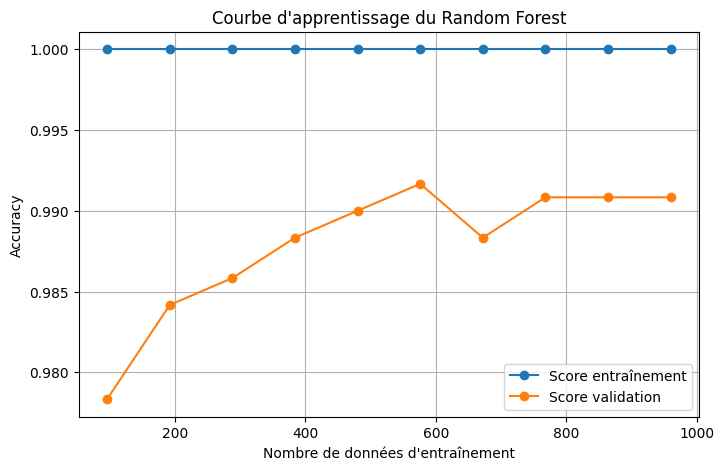

In [158]:
# Importer la fonction permettant de calculer une courbe d'apprentissage
from sklearn.model_selection import learning_curve

# Calculer les scores d'entraînement et de validation
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=RandomForestClassifier(random_state=42),
    X=X_train,
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Calculer la moyenne des scores pour chaque taille d'échantillon
train_scores_mean = train_scores.mean(axis=1)
validation_scores_mean = validation_scores.mean(axis=1)

# Tracer la courbe d'apprentissage
plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_scores_mean,
    marker="o",
    label="Score entraînement"
)

plt.plot(
    train_sizes,
    validation_scores_mean,
    marker="o",
    label="Score validation")

plt.xlabel("Nombre de données d'entraînement")
plt.ylabel("Accuracy")
plt.title("Courbe d'apprentissage du Random Forest")
plt.legend()
plt.grid()

plt.show()

In [159]:
# Prédire la classe des billets du jeu de test
y_pred_rf = random_forest.predict(X_test)

# Afficher les 10 premières prédictions
print(y_pred_rf[:10])

[ True False False  True  True  True  True  True  True  True]


## K-means

K-means est un algorithme non supervisé : contrairement aux modèles précédents, il n'utilise pas la variable cible `is_genuine` pour apprendre.

Il regroupe les billets selon la similarité de leurs caractéristiques géométriques. Deux clusters sont définis afin d'étudier si ces groupes peuvent correspondre aux billets authentiques et aux faux billets.

In [160]:
from sklearn.cluster import KMeans

# Initialiser K-means avec 2 groupes
kmeans = KMeans(
    n_clusters=2,
    random_state=42)

In [161]:
# Entraîner K-means sur les données d'entraînement
kmeans.fit(X_train)

KMeans(n_clusters=2, random_state=42)

In [162]:
# Déterminer le cluster des billets du jeu de test
clusters_test = kmeans.predict(X_test)

# Afficher les 10 premiers clusters
print(clusters_test[:10])

[1 0 0 1 1 1 1 1 1 1]


In [163]:
# Créer un tableau pour comparer les clusters K-means
# avec la vraie classe des billets du jeu de test
comparaison_kmeans = pd.DataFrame({
    "cluster": clusters_test,
    "is_genuine": y_test.values
})

# Afficher les premières lignes
comparaison_kmeans.head()

,cluster,is_genuine
0,1,True
1,0,False
2,0,False
3,1,True
4,1,True


In [164]:
# Comparer les clusters K-means avec les vraies classes des billets
# afin de comprendre ce que représente chaque cluster
repartition_clusters = pd.crosstab(
    comparaison_kmeans["cluster"],
    comparaison_kmeans["is_genuine"]
)

# Afficher la répartition des billets faux et authentiques
# dans chacun des deux clusters
print(repartition_clusters)

is_genuine  False  True 
cluster                 
0              95      1
1               5    199


In [165]:
# Ajouter le numéro du cluster aux données du jeu de test
X_test_clusters = X_test.copy()
X_test_clusters["cluster"] = clusters_test

# Calculer la moyenne de chaque caractéristique géométrique
# pour chacun des deux clusters
caracteristiques_clusters = X_test_clusters.groupby("cluster").mean()

# Afficher les caractéristiques moyennes des clusters
display(caracteristiques_clusters)

,diagonal,height_left,height_right,margin_low,margin_up,length
cluster,,,,,,
0,171.919792,104.203021,104.159063,5.237027,3.340313,111.620833
1,171.970245,103.935980,103.815245,4.093411,3.060245,113.238137


### Caractérisation des clusters K-means

K-means a créé deux groupes sans utiliser la variable cible `is_genuine`.

La comparaison avec les classes réelles montre que :

- le cluster 0 contient 95 faux billets et 1 billet authentique : il correspond donc principalement aux faux billets ;
- le cluster 1 contient 199 billets authentiques et 5 faux billets : il correspond donc principalement aux billets authentiques.

L'analyse des caractéristiques moyennes montre également des différences entre les deux groupes. Le cluster 0, principalement composé de faux billets, présente notamment un `margin_low` moyen plus élevé (environ 5,24 contre 4,09) et une `length` moyenne plus faible (environ 111,62 contre 113,24).

K-means parvient donc à faire apparaître naturellement deux groupes fortement associés aux billets faux et authentiques, bien qu'il n'ait pas utilisé `is_genuine` lors de son entraînement.

In [166]:
# Importer le score de silhouette pour évaluer la qualité des clusters
from sklearn.metrics import silhouette_score

# Calculer le score de silhouette obtenu par K-means
# Plus le score est proche de 1, plus les clusters sont compacts et bien séparés
score_silhouette = silhouette_score(X_test, clusters_test)

# Afficher le résultat
print("Score de silhouette :", score_silhouette)

Score de silhouette : 0.5051922982244861


### Évaluation des clusters

Le score de silhouette obtenu est d'environ **0,51**.

Ce score indique que les deux clusters présentent une séparation correcte, même s'ils ne sont pas parfaitement distincts.

Cette analyse confirme que K-means parvient à identifier une structure naturelle en deux groupes dans les données.

# Sélection du meilleur modèle


In [167]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report)

In [168]:
# Comparer l'accuracy des modèles supervisés

accuracy_log = accuracy_score(y_test, y_pred_log)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Régression logistique :", accuracy_log)
print("KNN :", accuracy_knn)
print("Random Forest :", accuracy_rf)

Régression logistique : 0.99
KNN : 0.99
Random Forest : 0.99


In [169]:
# Matrices de confusion des trois modèles

print("Régression logistique")
print(confusion_matrix(y_test, y_pred_log))

print("\nKNN")
print(confusion_matrix(y_test, y_pred_knn))

print("\nRandom Forest")
print(confusion_matrix(y_test, y_pred_rf))

Régression logistique
[[ 98   2]
 [  1 199]]

KNN
[[ 98   2]
 [  1 199]]

Random Forest
[[ 98   2]
 [  1 199]]


In [170]:
# Sensibilité pour la détection des faux billets
#Parmi les faux billets, combien j'arrive à détecter ?
sensibilite_faux_log = recall_score(
    y_test,
    y_pred_log,
    pos_label=False
)

print("Sensibilité aux faux billets :", sensibilite_faux_log)

Sensibilité aux faux billets : 0.98


In [171]:
# Spécificité : Parmi les vrais billets, combien j'arrive à reconnaître correctement ?
specificite_log = recall_score(
    y_test,
    y_pred_log,
    pos_label=True)

print("Spécificité :", specificite_log)

Spécificité : 0.995


In [172]:
# Probabilité qu'un billet appartienne à la classe True (authentique)
proba_log = log_reg.predict_proba(X_test)[:, 1]
proba_knn = knn.predict_proba(X_test)[:, 1]
proba_rf = random_forest.predict_proba(X_test)[:, 1]

In [173]:
# Calculer l'AUC de chaque modèle à partir des vraies classes
# et des probabilités prédites pour la classe True (billet authentique)

auc_log = roc_auc_score(y_test, proba_log)
auc_knn = roc_auc_score(y_test, proba_knn)
auc_rf = roc_auc_score(y_test, proba_rf)

# Afficher les résultats pour comparer les trois modèles
print("AUC Régression logistique :", auc_log)
print("AUC KNN :", auc_knn)
print("AUC Random Forest :", auc_rf)

AUC Régression logistique : 0.9993000000000001
AUC KNN : 0.99215
AUC Random Forest : 0.99935


### Comparaison des AUC

Les trois modèles présentent une excellente capacité à distinguer les billets authentiques des faux billets.

- Régression logistique : AUC ≈ 0,9993
- KNN : AUC ≈ 0,9922
- Random Forest : AUC ≈ 0,9994

Le Random Forest obtient l'AUC la plus élevée, très légèrement devant la régression logistique.
Le KNN présente une AUC légèrement inférieure.

In [174]:
# Importer la fonction permettant de calculer la courbe ROC
from sklearn.metrics import roc_curve

# Calculer les taux de faux positifs (FPR) et de vrais positifs (TPR)
# à partir des probabilités prédites par chaque modèle
fpr_log, tpr_log, _ = roc_curve(y_test, proba_log)
fpr_knn, tpr_knn, _ = roc_curve(y_test, proba_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)

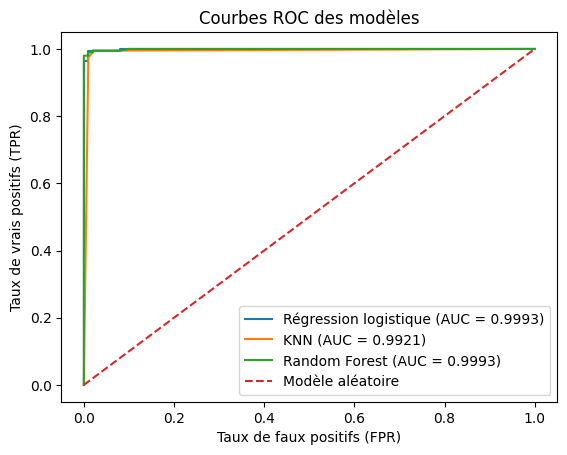

In [175]:
# Importer matplotlib pour tracer les courbes
import matplotlib.pyplot as plt

# Tracer la courbe ROC de chaque modèle
plt.plot(fpr_log, tpr_log, label=f"Régression logistique (AUC = {auc_log:.4f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})")

# Ajouter la diagonale représentant un modèle aléatoire
plt.plot([0, 1], [0, 1], linestyle="--", label="Modèle aléatoire")

# Ajouter les informations du graphique
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbes ROC des modèles")
plt.legend()

# Afficher le graphique
plt.show()

### Interprétation de la courbe ROC

Les courbes ROC des trois modèles sont très proches du coin supérieur gauche, ce qui indique une excellente capacité à distinguer les deux classes.

Le Random Forest et la régression logistique présentent les meilleures AUC, avec des performances très proches. Le KNN obtient une AUC légèrement inférieure.

La courbe ROC confirme donc les très bonnes performances observées précédemment avec l'accuracy et la matrice de confusion.

### Sélection du meilleur modèle

Les trois modèles supervisés présentent d'excellentes performances avec une accuracy de 99 % et une même capacité à détecter les faux billets sur le jeu de test.

La comparaison des AUC permet toutefois de les départager :

- Régression logistique : AUC ≈ 0,99930
- KNN : AUC ≈ 0,99215
- Random Forest : AUC ≈ 0,99935

Le Random Forest obtient l'AUC la plus élevée, bien que son résultat soit très proche de celui de la régression logistique.

Le Random Forest est donc retenu comme modèle final.

# Sauvegarde du meilleur modèle

In [176]:
import joblib
# Définir le chemin de sauvegarde dans Google Drive
chemin_modele = "/content/drive/MyDrive/Colab Notebooks/P12/modele_random_forest.pkl"

# Sauvegarder le modèle Random Forest dans Google Drive
joblib.dump(random_forest, chemin_modele)

# Confirmer la sauvegarde
print("Modèle sauvegardé dans Google Drive.")

Modèle sauvegardé dans Google Drive.


In [177]:
# Vérifier que le fichier a bien été sauvegardé
import os

print(os.path.exists(chemin_modele))

True


### Sauvegarde du modèle final

Le Random Forest a été retenu comme modèle final à l'issue de la comparaison des performances.

Le modèle entraîné est sauvegardé avec `joblib` afin de pouvoir être réutilisé pour effectuer des prédictions sur de nouveaux billets sans avoir à l'entraîner de nouveau.

Aucun `StandardScaler` n'est intégré, car le modèle final est un Random Forest et la standardisation n'a pas été retenue dans le prétraitement.